# zedstat ROC convex-hull diagnostic

This notebook tests the current `zedstat` convex-hull path on the NERO ROC data without the older notebook's sampling/counting ambiguities.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from zedstat import zedstat

# ytrue.csv was written with a pandas index, so read that index back as index.
# The remaining single column is the actual binary label vector.
ytrue = pd.read_csv('notebooks/ytrue.csv', index_col=0).iloc[:, 0].to_numpy(dtype=int)
roc_df = pd.read_csv('notebooks/neroroce.csv')

print('n =', len(ytrue))
print('class counts:', {0: int(np.sum(ytrue == 0)), 1: int(np.sum(ytrue == 1))})
print(roc_df[['fpr', 'tpr']].describe())

n = 6886
class counts: {0: 4383, 1: 2503}
               fpr          tpr
count  5427.000000  5427.000000
mean      0.441622     0.640609
std       0.297159     0.240178
min       0.000000     0.000000
25%       0.175390     0.461442
50%       0.412705     0.683322
75%       0.689573     0.843943
max       1.000000     1.000000


In [27]:
# neroroce.csv was constructed with pos_label=0, therefore positive_samples
# must count class 0, not ytrue.sum().
zte = zedstat.processRoc(
    df=roc_df,
    total_samples=len(ytrue),
    positive_samples=int(np.sum(ytrue == 0)),
    alpha=0.01,
    prevalence=0.5,
)

# STEP is FPR grid resolution, not smoothing strength. Keep it fine.
zte.smooth(STEP=0.001, interpolate=True, convexify=True)
zte.allmeasures(interpolate=False)
zte.getBounds()

print('AUC (nominal, upper, lower):', zte.auc(alpha=0.05))

AUC (nominal, upper, lower): (0.7184941638592834, np.float64(0.7304243847686873), np.float64(0.7065639429498796))


strictly increasing FPR: True
nondecreasing TPR: False
concave / ROCCH slopes non-increasing: False
largest slope increase: 591.8794204882497


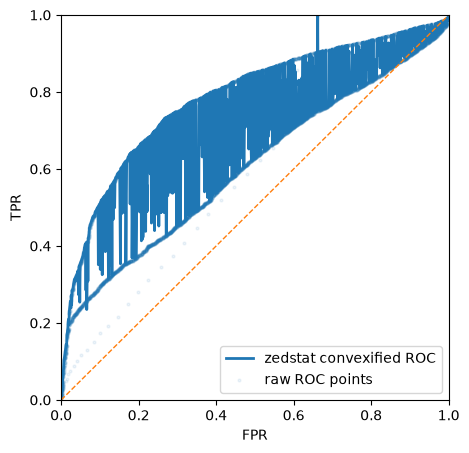

In [28]:
# Verify that the nominal curve returned by zedstat is a valid upper ROC hull:
# TPR must be nondecreasing and secant slopes must be non-increasing.
out = zte.get()[['tpr']].copy()
fpr = out.index.to_numpy(dtype=float)
tpr = out['tpr'].to_numpy(dtype=float)
dx = np.diff(fpr)
dy = np.diff(tpr)
slopes = dy / dx
tol = 1e-9

print('strictly increasing FPR:', bool(np.all(dx > 0)))
print('nondecreasing TPR:', bool(np.all(dy >= -tol)))
print('concave / ROCCH slopes non-increasing:', bool(np.all(np.diff(slopes) <= tol)))
print('largest slope increase:', float(np.max(np.diff(slopes))))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, lw=2, label='zedstat convexified ROC')
ax.scatter(roc_df['fpr'], roc_df['tpr'], s=4, alpha=0.08, label='raw ROC points')
ax.plot([0, 1], [0, 1], '--', lw=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
plt.show()

If the last diagnostic reports a positive slope increase materially above numerical tolerance, the defect is in `zedstat`'s convexification/resampling path rather than in the NERO notebook.